Based on https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter16.04-Least-Squares-Regression-in-Python.html

Una función y(x) representada como una combinación lineal de $M$ funciones f(x) escaladas por un factor $\alpha$:

$$
\begin{align}
y_1 &\approx \alpha_1 f_1(x_1) + \alpha_2 f_2(x_1) + \dots + \alpha_M f_M(x_1) \\
y_2 &\approx \alpha_1 f_1(x_2) + \alpha_2 f_2(x_2) + \dots + \alpha_M f_M(x_2) \\
&\vdots  \\
y_N &\approx \alpha_1 f_1(x_N) + \alpha_2 f_2(x_N) + \dots + \alpha_M f_M(x_N) \\
\end{align}
$$

Representado como matrices se expresa como:
$$Y=A\beta$$

, donde:
$$
Y = 
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_N
\end{bmatrix}
\qquad
A = 
\begin{bmatrix}
f_1(x_1) & f_2(x_1) & \dots & f_M(x_1) \\
f_1(x_2) & f_2(x_2) & \dots & f_M(x_2) \\
f_1(x_N) & f_2(x_N) & \dots & f_M(x_N) \\
\end{bmatrix}
\qquad
\beta = 
\begin{bmatrix}
\alpha_1 \\
\alpha_2 \\
\vdots \\
\alpha_M \\
\end{bmatrix}
$$


La solución de $\beta$ que se obtiene aplicando LSQ es:
$$
\beta = (A^T A)^{-1} A^T Y
$$

El termino:
$$(A^T A)^{-1} A^T$$
se denomina la **pseudo-inversa** de $A$.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Consider the artificial data created by `x = np.linspace(0, 1, 101)`.

Where the original function is `y = 1 + x + x * np.random.random(len(x))`.
(note that some random noise is added with the term `x * np.random.random(len(x))`).


- Do a least squares regression with an estimation function defined by $\hat y = α_1x+α_2$
- Plot the data points along with the least squares regression. Note that we expect `α1=1.5` and `α2=1.0` based on this data. Due to the random noise we added into the data, your results maybe slightly different

In [29]:
# generate x and y
x = np.linspace(0, 1, 101)

noise = x * np.random.random(len(x))
y = 1 + x + noise

## matrices
Matriz A de funciones (en base a la función de estimación $\hat y = \alpha_1 x + \alpha_2$):
$$
A = 
\begin{bmatrix}
x_1 & 1 \\
x_2 & 1 \\
\vdots \\
x_{len(x)} & 1 \\
\end{bmatrix}
$$

Matriz de las variables desconocidas:
$$
\beta =
\begin{bmatrix}
\alpha_1 \\
\alpha_2
\end{bmatrix}
$$

In [17]:
A = np.vstack((x, np.ones(len(x))))
print("Shape: ", A.shape)
# result: 2xN matrix

A[0][:10], A[1][:10]

Shape:  (2, 101)


(array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

In [18]:
# transpose A to get Nx2
A = A.T
A[:5]

array([[0.  , 1.  ],
       [0.01, 1.  ],
       [0.02, 1.  ],
       [0.03, 1.  ],
       [0.04, 1.  ]])

In [ ]:
# turn y (originally a row vector) into a column vector (new shape is Nx1)
y = y[:, np.newaxis]

# (np.newaxis is an alias for None)
y.shape

(101, 1)

In [31]:
# Direct least square regression
alpha = np.dot((np.dot(np.linalg.inv(np.dot(A.T,A)),A.T)),y)
print(alpha)

[[1.49870942]
 [1.0075215 ]]


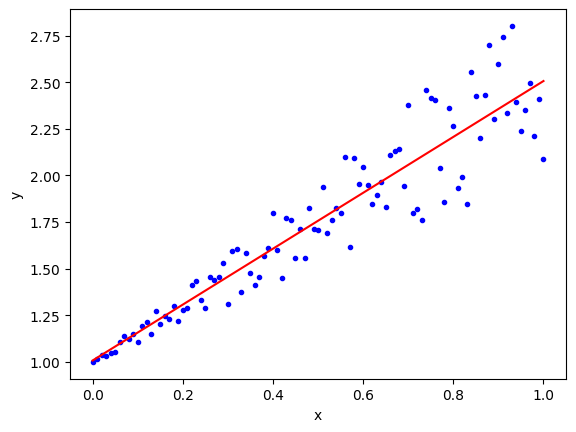

In [34]:
# plot the results
# plt.figure(figsize = (10,8))
plt.plot(x, y, 'b.')
plt.plot(x, alpha[0]*x + alpha[1], 'r')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Alternatively, use numpy's builtin function to calculate the pseudo-inverse:

In [36]:
pinv = np.linalg.pinv(A)
alpha = pinv.dot(y)
print(alpha)

[[1.49870942]
 [1.0075215 ]]


Alternatively, use numpy's builtin `numpy.linalg.lstsq`:



In [37]:
alpha = np.linalg.lstsq(A, y, rcond=None)[0]
print(alpha)

[[1.49870942]
 [1.0075215 ]]


# Diode capacitance example

Ejemplo de LSQ aplicado a la resolución de un problema no lineal.

https://www.youtube.com/watch?v=jezAWd6GFRg

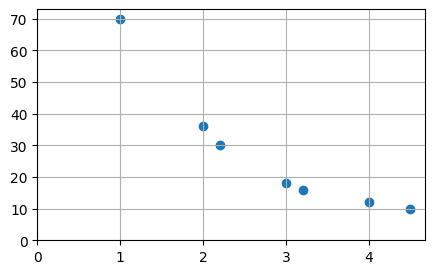

In [58]:
v = np.array([1, 2, 2.2, 3, 3.2, 4, 4.5])
C = np.array([70, 36, 30, 18, 16, 12, 10])

plt.figure(figsize=(5,3))
plt.scatter(v, C)
plt.xticks(np.arange(0, 5))
plt.yticks(np.arange(0, 71, 10))
plt.grid()

In [38]:
A = np.vstack((np.ones(len(v)), np.log(0.7+v))).T
A.shape

(7, 2)

In [42]:
y = np.log(C)

In [46]:
b, *_ = np.linalg.lstsq(A, y)
b

array([ 5.26205373, -1.79210965])

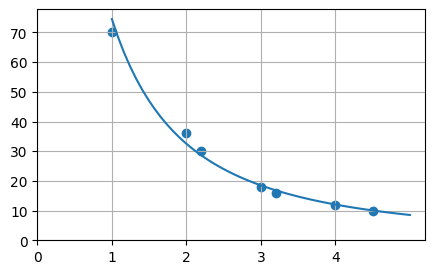

In [57]:
plt.figure(figsize=(5,3))
plt.scatter(v, C)

# plot estimated model:
Cj = np.exp(b[0])
gamma = -b[1]
vv = np.linspace(1, 5, 50)
plt.plot(vv, Cj/np.pow(0.7+vv, gamma))

plt.xticks(np.arange(0, 5))
plt.yticks(np.arange(0, 71, 10))
plt.grid()